k-means clusturing

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [15]:
data = {
    "Age": [19,21,20,23,31,22,35,23,64,30,67,35,58,24,37,22,35,20,52,35],
    "Annual Income": [15,15,16,16,17,17,18,18,19,19,20,20,21,21,22,22,23,23,24,24],
    "Spending Score": [39,81,6,77,40,76,6,94,3,72,14,99,15,77,13,79,35,66,29,98]
}

In [16]:
df = pd.DataFrame(data)
df

,Age,Annual Income,Spending Score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
5,22,17,76
6,35,18,6
7,23,18,94
8,64,19,3
9,30,19,72


In [17]:
scalar = StandardScaler()
x_scaled = scalar.fit_transform(df)

In [18]:
kmeans = KMeans(n_clusters=4,init="k-means++",max_iter=500,random_state=42)

In [19]:
kmeans.fit(x_scaled)    

KMeans(max_iter=500, n_clusters=4, random_state=42)

In [20]:
df['Cluster'] = kmeans.labels_
df

,Age,Annual Income,Spending Score,Cluster
0,19,15,39,2
1,21,15,81,0
2,20,16,6,2
3,23,16,77,0
4,31,17,40,2
5,22,17,76,0
6,35,18,6,2
7,23,18,94,0
8,64,19,3,1
9,30,19,72,0


In [21]:
print(kmeans.cluster_centers_)

[[-0.54190964 -0.69631062  0.96792256]
 [ 1.48996868  0.59186403 -1.08609624]
 [-0.50231291 -1.04446594 -0.8472452 ]
 [-0.43782679  1.07928147  0.60238533]]


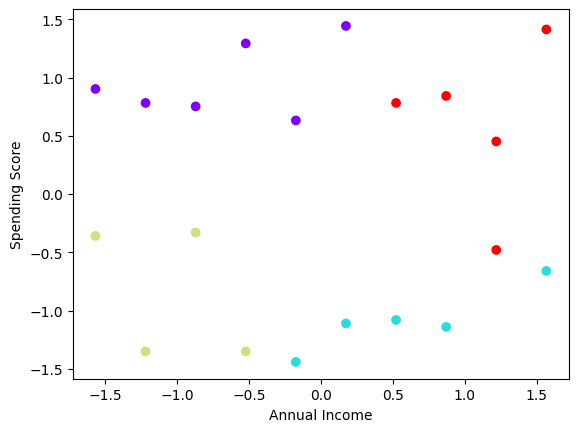

In [22]:
plt.scatter(x_scaled[:,1],x_scaled[:,2],c=kmeans.labels_,cmap='rainbow')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

In [23]:
new_cust = pd.DataFrame({"Age": [29],"Annual Income": [20],"Spending Score": [80]})
print(new_cust)

   Age  Annual Income  Spending Score
0   29             20              80


In [24]:
new_cust_scaled = scalar.transform(new_cust)
print(new_cust_scaled)

[[-0.31564257  0.17407766  0.87278273]]


In [25]:
cluster =  kmeans.predict(new_cust_scaled)[0]
print(cluster)


0


In [26]:
if(cluster == 0 or cluster == 1):
    print("not buy")
else:
    print("buy")

not buy
